# 📊 PROYECTO: ANÁLISIS ECONÓMICO DE MIPYMES EN CUBA
## Ciencia de Datos - Programación
### Primer Año - Semestre 2025

**Autor:** [Tu Nombre]
**Fecha:** Enero 2025
**Institución:** [Tu Universidad]

---

## 📌 INTRODUCCIÓN: LA REALIDAD ECONÓMICA CUBANA

Cuba enfrenta una compleja situación económica caracterizada por:
- **Dualidad monetaria** (CUP vs MLC/USD)
- **Escasez de productos** básicos
- **Sector privado emergente** (MIPYMES)
- **Brecha salarial** significativa entre sectores

Este proyecto analiza la **accesibilidad a productos básicos** a través del estudio de 30 MIPYMES en La Habana, combinando datos de precios, disponibilidad, ubicación geográfica y salarios oficiales.

**Objetivos del análisis:**
1. 📋 Evaluar disponibilidad de 12 productos básicos
2. 💰 Comparar precios entre municipios
3. 🏙️ Analizar distribución geográfica de costos
4. 💼 Medir asequibilidad vs salarios oficiales
5. 🔄 [PENDIENTE: Análisis con tercera fuente]

**Metodología:** Análisis cuantitativo basado en datos recolectados de 30 MIPYMES en 6 municipios de La Habana.

In [2]:
# %% [code]
# ============================================================================
# CONFIGURACIÓN Y CARGA DE DATOS
# ============================================================================

import json
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os
import sys

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.figsize'] = (14, 7)
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Colores personalizados para el proyecto
COLORES_CUBA = {
    'azul': '#1f77b4',
    'naranja': '#ff7f0e',
    'rojo': '#d62728',
    'verde': '#2ca02c',
    'morado': '#9467bd',
    'cafe': '#8c564b'
}

print("=" * 70)
print("📊 PROYECTO DE ANÁLISIS ECONÓMICO CUBA")
print("📁 CARGANDO RESULTADOS DEL ANÁLISIS...")
print("=" * 70)

📊 PROYECTO DE ANÁLISIS ECONÓMICO CUBA
📁 CARGANDO RESULTADOS DEL ANÁLISIS...


In [11]:
# %% [code]
def cargar_resultados(nombre_archivo):
    """
    Carga archivos JSON desde Data/Procesados/
    Retorna los datos o None si hay error
    """
    ruta = f'../Data/Procesados/{nombre_archivo}'

    try:
        with open(ruta, 'r', encoding='utf-8') as f:
            datos = json.load(f)
        print(f"✅ {nombre_archivo:30} → Cargado")
        return datos
    except FileNotFoundError:
        print(f"❌ {nombre_archivo:30} → No encontrado en {ruta}")
        return None
    except json.JSONDecodeError as e:
        print(f"❌ {nombre_archivo:30} → Error JSON: {e}")
        return None
    except Exception as e:
        print(f"❌ {nombre_archivo:30} → Error: {e}")
        return None

# Cargar TODOS los archivos generados
productos_planos = cargar_resultados('productos_planos.json')
disponibilidad = cargar_resultados('analisis_disponibilidad.json')
precios = cargar_resultados('analisis_precios.json')
geografico = cargar_resultados('analisis_geografico.json')
asequibilidad = cargar_resultados('analisis_asequibilidad.json')

print("-" * 70)

✅ productos_planos.json          → Cargado
✅ analisis_disponibilidad.json   → Cargado
✅ analisis_precios.json          → Cargado
✅ analisis_geografico.json       → Cargado
✅ analisis_asequibilidad.json    → Cargado
----------------------------------------------------------------------


In [12]:
# %% [code]
# Verificar que todos los datos se cargaron
datos_cargados = all([productos_planos, disponibilidad, precios, geografico, asequibilidad])

if datos_cargados:
    print("🎯 RESUMEN DE DATOS CARGADOS:")
    print(f"   • {len(productos_planos)} productos disponibles en MIPYMES")
    print(f"   • {len(disponibilidad['por_producto'])} productos analizados para disponibilidad")
    print(f"   • {len(precios)} productos con análisis de precios detallado")
    print(f"   • {len(geografico)} municipios analizados geográficamente")
    print(f"   • {len(asequibilidad)} productos analizados para asequibilidad vs salarios")
    print("\n✅ ¡Todo listo para el análisis!")
else:
    print("⚠️  Algunos archivos no se cargaron. Verifica las rutas.")
    print("   Ejecuta primero: python Src/analisis.py")

print("=" * 70)

🎯 RESUMEN DE DATOS CARGADOS:
   • 243 productos disponibles en MIPYMES
   • 12 productos analizados para disponibilidad
   • 12 productos con análisis de precios detallado
   • 6 municipios analizados geográficamente
   • 12 productos analizados para asequibilidad vs salarios

✅ ¡Todo listo para el análisis!


## 📋 ANÁLISIS 1: DISPONIBILIDAD DE PRODUCTOS

**Pregunta de investigación:** ¿Qué productos son más difíciles de encontrar en las MIPYMES de La Habana?

**Metodología:**
- Se analizaron 30 MIPYMES × 12 productos = 360 productos posibles
- Productos con precio `null` = NO DISPONIBLES
- Cálculo: `% Disponibilidad = (Productos con precio / Total posible) × 100`

**Significado de colores:**
- 🔴 **Rojo:** Menos del 50% de disponibilidad (muy difícil encontrar)
- 🟠 **Naranja:** 50-70% de disponibilidad (moderadamente difícil)
- 🟢 **Verde:** Más del 70% de disponibilidad (relativamente fácil)


📈 GENERANDO GRÁFICO 1: DISPONIBILIDAD DE PRODUCTOS


C:\Users\Elio\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


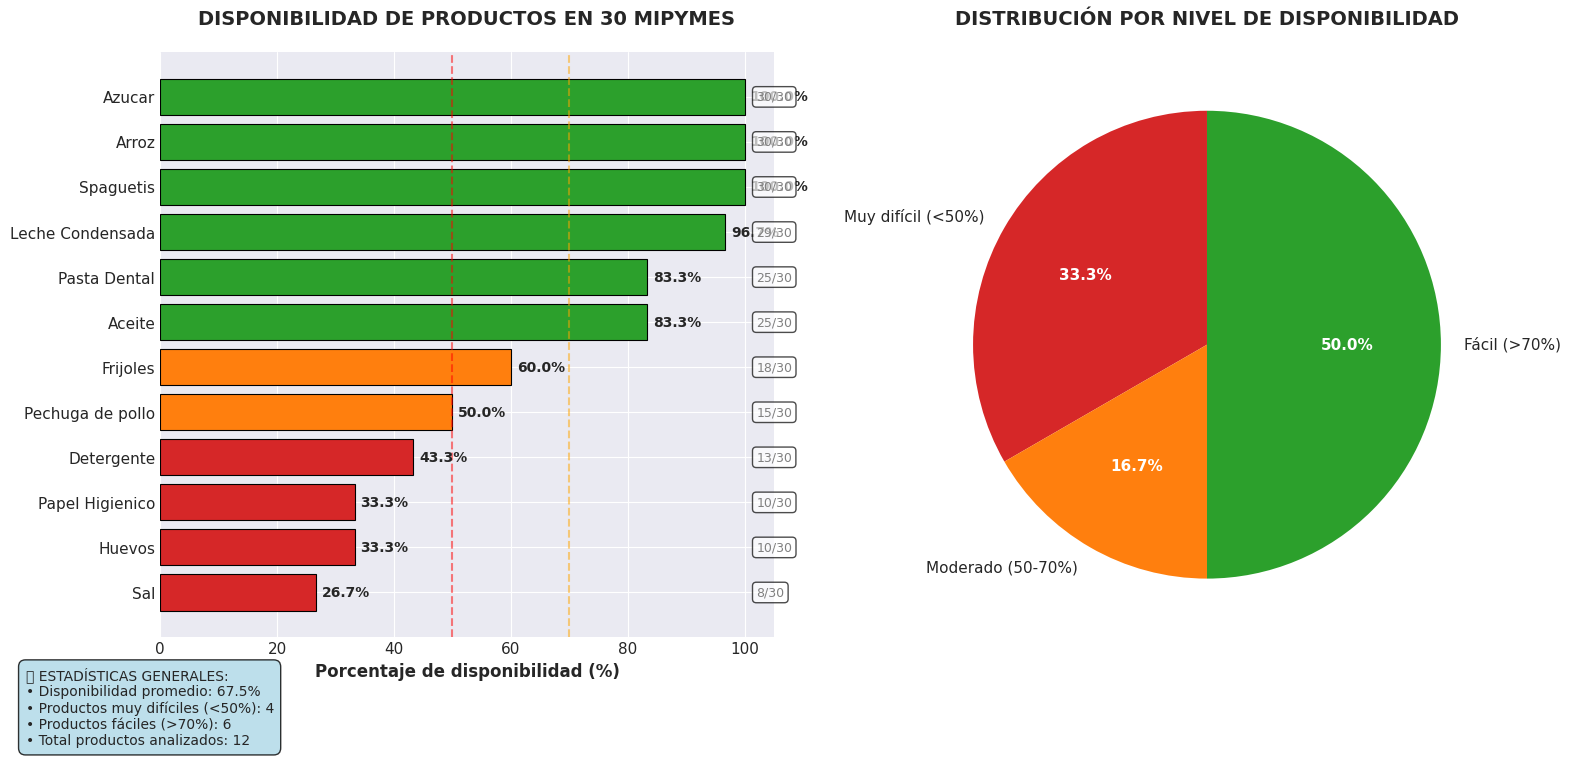


🔍 PRODUCTOS MÁS DIFÍCILES DE ENCONTRAR (<50% disponibilidad):
   • Sal: 26.7%
   • Huevos: 33.3%
   • Papel Higienico: 33.3%
   • Detergente: 43.3%

✅ Gráfico 1 generado exitosamente


In [13]:
# %% [code]
# ============================================================================
# GRÁFICO 1: DISPONIBILIDAD DE PRODUCTOS
# ============================================================================

print("\n" + "=" * 70)
print("📈 GENERANDO GRÁFICO 1: DISPONIBILIDAD DE PRODUCTOS")
print("=" * 70)

# Extraer datos de disponibilidad
productos_disp = disponibilidad['por_producto']

# Ordenar por disponibilidad (menor a mayor)
productos_ordenados = sorted(
    productos_disp.items(),
    key=lambda x: x[1]['porcentaje_disponible']
)

# Preparar datos para el gráfico
nombres = [p[0] for p in productos_ordenados]
porcentajes = [p[1]['porcentaje_disponible'] for p in productos_ordenados]
totales = [p[1]['total'] for p in productos_ordenados]
disponibles = [p[1]['disponible'] for p in productos_ordenados]

# Crear figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# ========== GRÁFICO DE BARRAS HORIZONTALES ==========
# Asignar colores según disponibilidad
colores = []
for porcentaje in porcentajes:
    if porcentaje < 50:
        colores.append(COLORES_CUBA['rojo'])      # Muy difícil
    elif porcentaje < 70:
        colores.append(COLORES_CUBA['naranja'])   # Moderado
    else:
        colores.append(COLORES_CUBA['verde'])     # Fácil

# Gráfico principal
bars = ax1.barh(nombres, porcentajes, color=colores, edgecolor='black', linewidth=0.8)
ax1.set_xlabel('Porcentaje de disponibilidad (%)', fontsize=12, fontweight='bold')
ax1.set_title('DISPONIBILIDAD DE PRODUCTOS EN 30 MIPYMES',
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlim(0, 105)

# Líneas de referencia
ax1.axvline(x=50, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='50% (Muy difícil)')
ax1.axvline(x=70, color='orange', linestyle='--', alpha=0.5, linewidth=1.5, label='70% (Fácil)')

# Añadir valores en barras
for i, (bar, porcentaje, disp, total) in enumerate(zip(bars, porcentajes, disponibles, totales)):
    # Porcentaje
    ax1.text(porcentaje + 1, bar.get_y() + bar.get_height()/2,
             f'{porcentaje:.1f}%', va='center', fontsize=10, fontweight='bold')

    # Conteo MIPYMES
    ax1.text(102, bar.get_y() + bar.get_height()/2,
             f"{disp}/{total}", va='center', fontsize=9, color='gray',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

# ========== GRÁFICO DE TORTA (RESUMEN) ==========
# Categorizar productos
categorias = {
    'Muy difícil (<50%)': sum(1 for p in porcentajes if p < 50),
    'Moderado (50-70%)': sum(1 for p in porcentajes if 50 <= p < 70),
    'Fácil (>70%)': sum(1 for p in porcentajes if p >= 70)
}

etiquetas = list(categorias.keys())
valores = list(categorias.values())
colores_torta = [COLORES_CUBA['rojo'], COLORES_CUBA['naranja'], COLORES_CUBA['verde']]

# Crear gráfico de torta
wedges, texts, autotexts = ax2.pie(valores, labels=etiquetas, colors=colores_torta,
                                   autopct='%1.1f%%', startangle=90,
                                   textprops={'fontsize': 11})

# Mejorar estética de la torta
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax2.set_title('DISTRIBUCIÓN POR NIVEL DE DISPONIBILIDAD',
              fontsize=14, fontweight='bold', pad=20)

# ========== ESTADÍSTICAS TEXTUALES ==========
# Calcular estadísticas
disponibilidad_promedio = sum(porcentajes) / len(porcentajes)
productos_muy_dificiles = [n for n, p in zip(nombres, porcentajes) if p < 50]
productos_faciles = [n for n, p in zip(nombres, porcentajes) if p >= 70]

# Añadir texto con estadísticas
estadisticas_texto = (
    f"📊 ESTADÍSTICAS GENERALES:\n"
    f"• Disponibilidad promedio: {disponibilidad_promedio:.1f}%\n"
    f"• Productos muy difíciles (<50%): {len(productos_muy_dificiles)}\n"
    f"• Productos fáciles (>70%): {len(productos_faciles)}\n"
    f"• Total productos analizados: {len(nombres)}"
)

fig.text(0.02, 0.02, estadisticas_texto, fontsize=10,
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))

plt.tight_layout(rect=[0, 0.08, 1, 0.96])  # Ajustar para el texto inferior
plt.show()

# Mostrar productos específicos en consola
print("\n🔍 PRODUCTOS MÁS DIFÍCILES DE ENCONTRAR (<50% disponibilidad):")
for producto in productos_muy_dificiles:
    porcentaje = next(p[1]['porcentaje_disponible'] for p in productos_ordenados if p[0] == producto)
    print(f"   • {producto}: {porcentaje:.1f}%")

print("\n✅ Gráfico 1 generado exitosamente")

## 💰 ANÁLISIS 2: VARIABILIDAD DE PRECIOS

**Pregunta de investigación:** ¿Cuánto cuestan los productos básicos y qué tan variables son sus precios?

**Metodología:**
- Análisis de precios en CUP (pesos cubanos)
- Cálculo de promedio, mínimo, máximo y rango
- Todos los precios convertidos a unidades comparables

**Conceptos clave:**
- **Rango de precios:** Diferencia entre precio más alto y más bajo
- **Desviación estándar:** Medida de variabilidad (valores altos = precios muy variables)
- **Precio por kg/unidad:** Normalizado para comparación justa


💰 GENERANDO GRÁFICO 2: ANÁLISIS DE PRECIOS


C:\Users\Elio\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


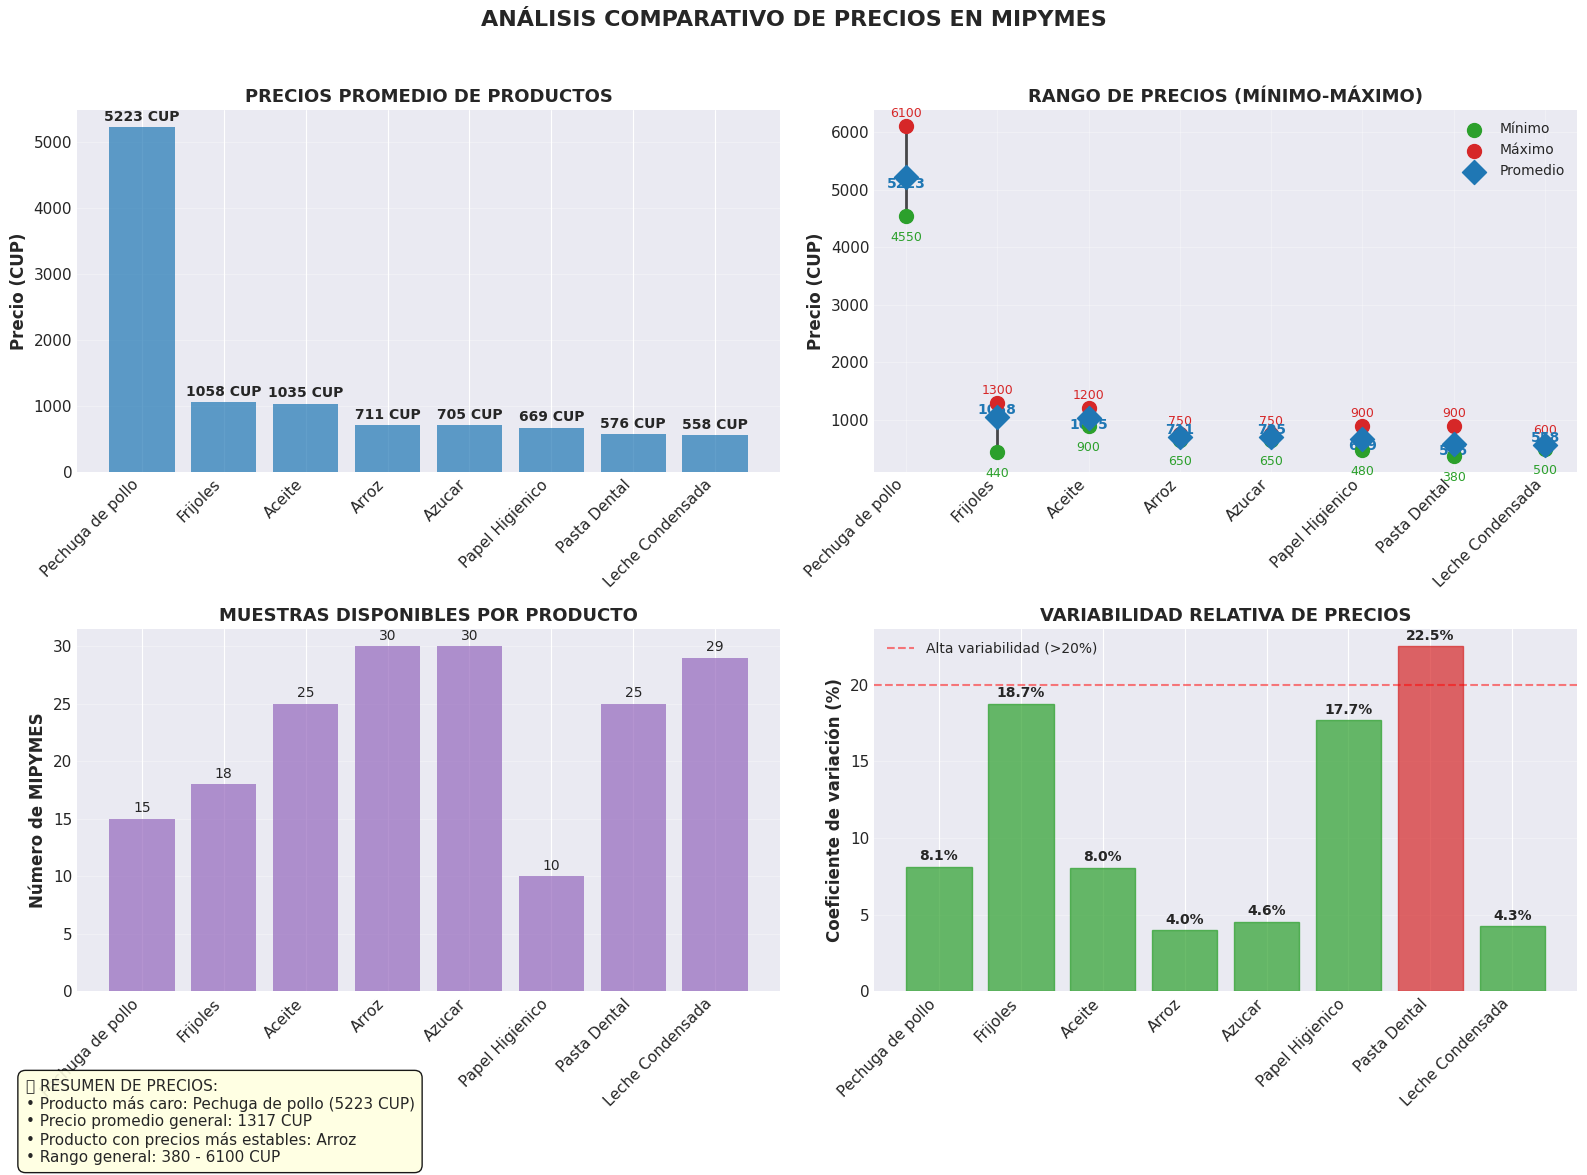


💰 PRODUCTO MÁS CARO: Pechuga de pollo → 5223 CUP
📏 PRODUCTO CON PRECIOS MÁS ESTABLES: Arroz
✅ Gráfico 2 generado exitosamente


In [14]:
# %% [code]
# ============================================================================
# GRÁFICO 2: ANÁLISIS DE PRECIOS
# ============================================================================

print("\n" + "=" * 70)
print("💰 GENERANDO GRÁFICO 2: ANÁLISIS DE PRECIOS")
print("=" * 70)

# Ordenar productos por precio promedio (más caro primero)
productos_por_precio = sorted(
    precios.items(),
    key=lambda x: x[1]['promedio'],
    reverse=True
)

# Tomar los 8 productos más caros para mejor visualización
top_productos = productos_por_precio[:8]

# Preparar datos
nombres = [p[0] for p in top_productos]
promedios = [p[1]['promedio'] for p in top_productos]
minimos = [p[1]['minimo'] for p in top_productos]
maximos = [p[1]['maximo'] for p in top_productos]
muestras = [p[1]['muestras'] for p in top_productos]
desviaciones = [p[1]['desviacion'] for p in top_productos]

# Crear figura con subgráficos
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ANÁLISIS COMPARATIVO DE PRECIOS EN MIPYMES',
             fontsize=16, fontweight='bold', y=0.98)

# ========== SUBGRÁFICO 1: PRECIOS PROMEDIO ==========
x_pos = np.arange(len(nombres))
bars1 = ax1.bar(x_pos, promedios, color=COLORES_CUBA['azul'], alpha=0.7, label='Precio promedio')
ax1.set_ylabel('Precio (CUP)', fontsize=12, fontweight='bold')
ax1.set_title('PRECIOS PROMEDIO DE PRODUCTOS', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(nombres, rotation=45, ha='right', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Añadir valores en barras
for i, (bar, precio) in enumerate(zip(bars1, promedios)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(promedios)*0.01,
             f'{precio:.0f} CUP', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ========== SUBGRÁFICO 2: RANGO DE PRECIOS ==========
# Crear gráfico de líneas para mostrar rango
for i, (min_val, max_val, promedio) in enumerate(zip(minimos, maximos, promedios)):
    # Línea vertical de rango
    ax2.plot([i, i], [min_val, max_val], color='black', linewidth=2, alpha=0.7)
    # Marcadores de mínimo y máximo
    ax2.scatter(i, min_val, color=COLORES_CUBA['verde'], s=100, zorder=5, label='Mínimo' if i==0 else "")
    ax2.scatter(i, max_val, color=COLORES_CUBA['rojo'], s=100, zorder=5, label='Máximo' if i==0 else "")
    # Línea de promedio
    ax2.scatter(i, promedio, color=COLORES_CUBA['azul'], s=150, marker='D', zorder=5, label='Promedio' if i==0 else "")

ax2.set_ylabel('Precio (CUP)', fontsize=12, fontweight='bold')
ax2.set_title('RANGO DE PRECIOS (MÍNIMO-MÁXIMO)', fontsize=13, fontweight='bold')
ax2.set_xticks(range(len(nombres)))
ax2.set_xticklabels(nombres, rotation=45, ha='right', fontsize=11)
ax2.grid(alpha=0.3)
ax2.legend(loc='upper right', fontsize=10)

# Añadir etiquetas de valores
for i, (min_val, max_val, promedio) in enumerate(zip(minimos, maximos, promedios)):
    ax2.text(i, min_val - max(promedios)*0.05, f'{min_val:.0f}',
             ha='center', va='top', fontsize=9, color=COLORES_CUBA['verde'])
    ax2.text(i, max_val + max(promedios)*0.02, f'{max_val:.0f}',
             ha='center', va='bottom', fontsize=9, color=COLORES_CUBA['rojo'])
    ax2.text(i, promedio, f'{promedio:.0f}',
             ha='center', va='bottom' if promedio > (min_val+max_val)/2 else 'top',
             fontsize=10, fontweight='bold', color=COLORES_CUBA['azul'])

# ========== SUBGRÁFICO 3: MUESTRAS POR PRODUCTO ==========
bars3 = ax3.bar(x_pos, muestras, color=COLORES_CUBA['morado'], alpha=0.7)
ax3.set_ylabel('Número de MIPYMES', fontsize=12, fontweight='bold')
ax3.set_title('MUESTRAS DISPONIBLES POR PRODUCTO', fontsize=13, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(nombres, rotation=45, ha='right', fontsize=11)
ax3.grid(axis='y', alpha=0.3)

# Añadir valores
for i, (bar, muestra) in enumerate(zip(bars3, muestras)):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(muestras)*0.01,
             f'{muestra}', ha='center', va='bottom', fontsize=10)

# ========== SUBGRÁFICO 4: VARIABILIDAD (DESVIACIÓN) ==========
# Calcular coeficiente de variación (desviación/promedio * 100)
coef_variacion = [(desv/prom)*100 for desv, prom in zip(desviaciones, promedios)]

bars4 = ax4.bar(x_pos, coef_variacion, color=COLORES_CUBA['naranja'], alpha=0.7)
ax4.set_ylabel('Coeficiente de variación (%)', fontsize=12, fontweight='bold')
ax4.set_title('VARIABILIDAD RELATIVA DE PRECIOS', fontsize=13, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(nombres, rotation=45, ha='right', fontsize=11)
ax4.grid(axis='y', alpha=0.3)
ax4.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='Alta variabilidad (>20%)')

# Añadir valores y colores según variabilidad
for i, (bar, cv) in enumerate(zip(bars4, coef_variacion)):
    color = COLORES_CUBA['rojo'] if cv > 20 else COLORES_CUBA['verde']
    bar.set_color(color)
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(coef_variacion)*0.01,
             f'{cv:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax4.legend(fontsize=10)

# ========== ESTADÍSTICAS GLOBALES ==========
precio_promedio_general = sum(promedios) / len(promedios)
producto_mas_caro = nombres[0]
precio_mas_caro = promedios[0]
producto_menos_variable = nombres[coef_variacion.index(min(coef_variacion))]

estadisticas_texto = (
    f"📊 RESUMEN DE PRECIOS:\n"
    f"• Producto más caro: {producto_mas_caro} ({precio_mas_caro:.0f} CUP)\n"
    f"• Precio promedio general: {precio_promedio_general:.0f} CUP\n"
    f"• Producto con precios más estables: {producto_menos_variable}\n"
    f"• Rango general: {min(minimos):.0f} - {max(maximos):.0f} CUP"
)

fig.text(0.02, 0.02, estadisticas_texto, fontsize=11,
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.9))

plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

print(f"\n💰 PRODUCTO MÁS CARO: {producto_mas_caro} → {precio_mas_caro:.0f} CUP")
print(f"📏 PRODUCTO CON PRECIOS MÁS ESTABLES: {producto_menos_variable}")
print("✅ Gráfico 2 generado exitosamente")

## 🏙️ ANÁLISIS 3: DISTRIBUCIÓN GEOGRÁFICA

**Pregunta de investigación:** ¿Existen diferencias en los precios según la ubicación geográfica en La Habana?

**Metodología:**
- Agrupación por municipio usando coordenadas GPS
- Cálculo de precio promedio por zona
- Análisis de disponibilidad geográfica

**Municipios analizados:**
1. H.Este (Habana del Este) - Zona residencial
2. Plaza (Plaza de la Revolución) - Zona céntrica
3. C.Habana (Centro Habana) - Zona popular
4. Vedado - Zona turística/residencial
5. Playa - Zona turística/residencial
6. H.Vieja (Habana Vieja) - Zona turística


📍 GENERANDO GRÁFICO 3: ANÁLISIS GEOGRÁFICO


C:\Users\Elio\AppData\Local\Temp\ipykernel_15232\768870013.py:104: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax4.boxplot(datos_por_municipio, labels=municipios, patch_artist=True)
C:\Users\Elio\AppData\Local\Temp\ipykernel_15232\768870013.py:144: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.05, 1, 0.96])
C:\Users\Elio\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127961 (\N{CITYSCAPE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


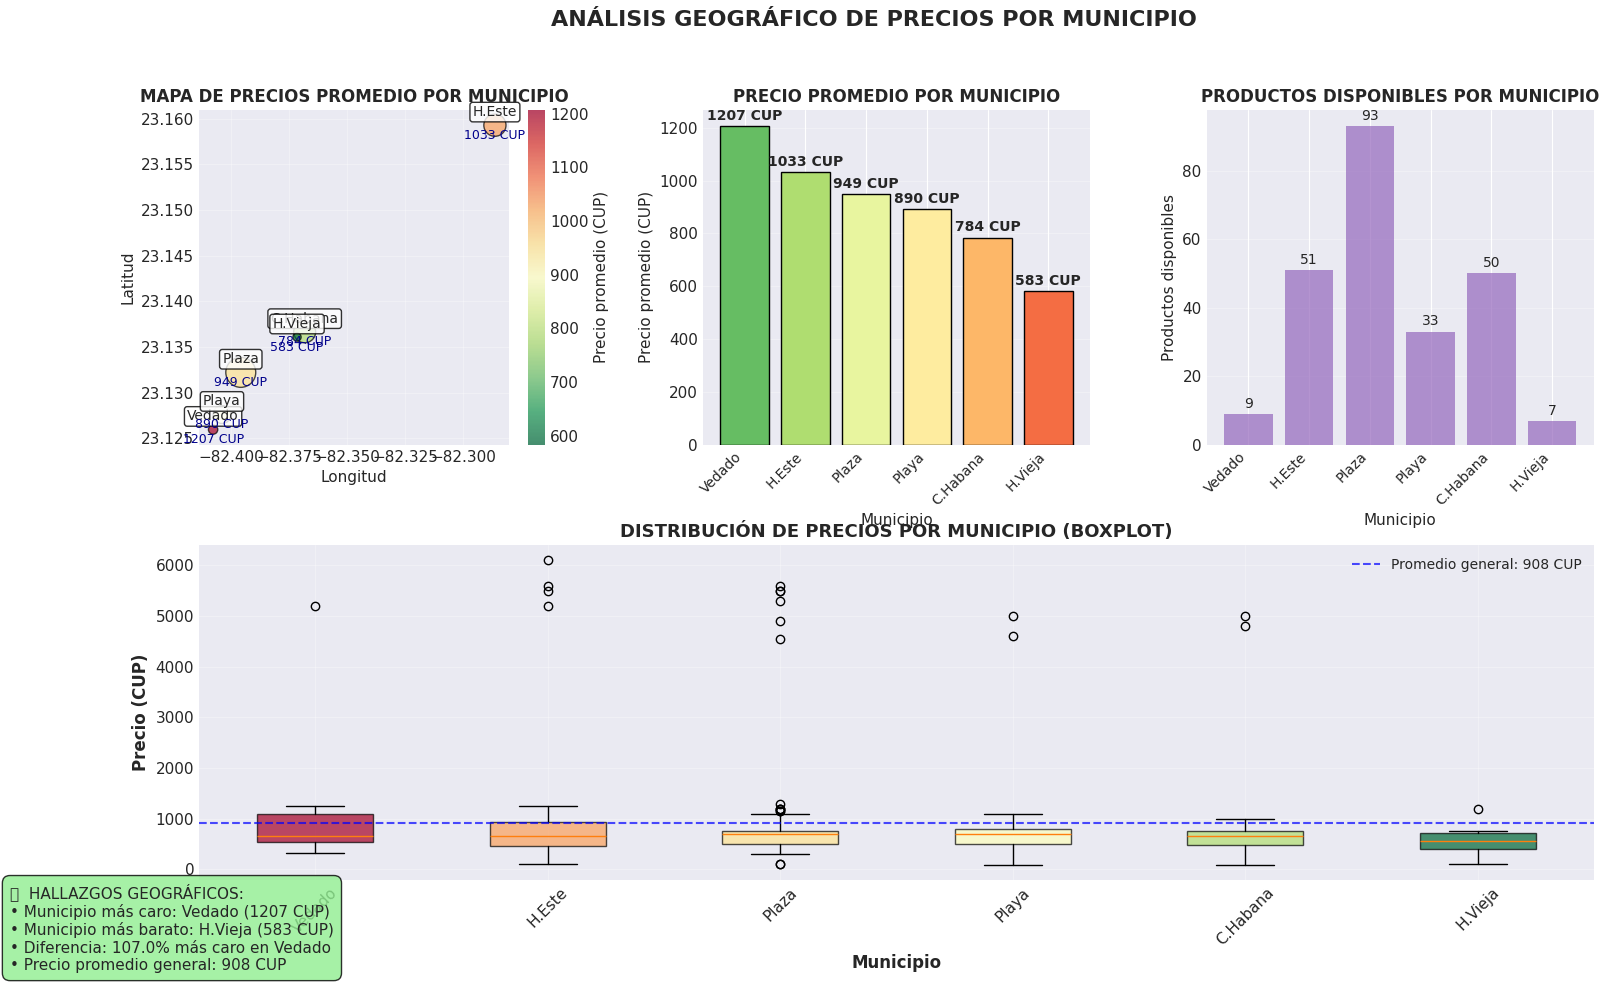


📍 MUNICIPIO MÁS CARO: Vedado → 1207 CUP
📍 MUNICIPIO MÁS BARATO: H.Vieja → 583 CUP
📏 DIFERENCIA: 107.0% más caro en Vedado
✅ Gráfico 3 generado exitosamente


In [15]:
# %% [code]
# ============================================================================
# GRÁFICO 3: ANÁLISIS GEOGRÁFICO
# ============================================================================

print("\n" + "=" * 70)
print("📍 GENERANDO GRÁFICO 3: ANÁLISIS GEOGRÁFICO")
print("=" * 70)

# Ordenar municipios por precio promedio (más caro primero)
municipios_ordenados = sorted(
    geografico.items(),
    key=lambda x: x[1]['precio_promedio'],
    reverse=True
)

# Preparar datos
municipios = [m[0] for m in municipios_ordenados]
precios_prom = [m[1]['precio_promedio'] for m in municipios_ordenados]
muestras = [m[1]['muestras'] for m in municipios_ordenados]
latitudes = [m[1]['latitud_promedio'] for m in municipios_ordenados]
longitudes = [m[1]['longitud_promedio'] for m in municipios_ordenados]

# Crear figura con múltiples visualizaciones
fig = plt.figure(figsize=(18, 10))
fig.suptitle('ANÁLISIS GEOGRÁFICO DE PRECIOS POR MUNICIPIO',
             fontsize=16, fontweight='bold', y=0.98)

# Definir layout de subgráficos
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# ========== SUBGRÁFICO 1: MAPA SIMBÓLICO ==========
ax1 = fig.add_subplot(gs[0, 0])
# Crear mapa simbólico con burbujas
scatter = ax1.scatter(longitudes, latitudes,
                      s=[m*5 for m in muestras],  # Tamaño por muestras
                      c=precios_prom,             # Color por precio
                      cmap='RdYlGn_r',           # Rojo (caro) a Verde (barato)
                      alpha=0.7,
                      edgecolors='black',
                      linewidths=1)

# Añadir etiquetas de municipios
for i, (mun, lon, lat, precio) in enumerate(zip(municipios, longitudes, latitudes, precios_prom)):
    ax1.text(lon, lat + 0.001, mun, fontsize=10, ha='center',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))
    # Añadir precio como etiqueta adicional
    ax1.text(lon, lat - 0.0015, f'{precio:.0f} CUP', fontsize=9, ha='center', color='darkblue')

ax1.set_xlabel('Longitud', fontsize=11)
ax1.set_ylabel('Latitud', fontsize=11)
ax1.set_title('MAPA DE PRECIOS PROMEDIO POR MUNICIPIO', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Añadir barra de color
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Precio promedio (CUP)', fontsize=11)

# ========== SUBGRÁFICO 2: BARRAS DE PRECIOS ==========
ax2 = fig.add_subplot(gs[0, 1])
x_pos = np.arange(len(municipios))
bars2 = ax2.bar(x_pos, precios_prom,
                color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(municipios))),
                edgecolor='black', linewidth=1)

ax2.set_xlabel('Municipio', fontsize=11)
ax2.set_ylabel('Precio promedio (CUP)', fontsize=11)
ax2.set_title('PRECIO PROMEDIO POR MUNICIPIO', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(municipios, rotation=45, ha='right', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Añadir valores en barras
for bar, precio in zip(bars2, precios_prom):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(precios_prom)*0.01,
             f'{precio:.0f} CUP', ha='center', va='bottom', fontsize=10, fontweight='bold')

# ========== SUBGRÁFICO 3: MUESTRAS POR MUNICIPIO ==========
ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(x_pos, muestras, color=COLORES_CUBA['morado'], alpha=0.7)
ax3.set_xlabel('Municipio', fontsize=11)
ax3.set_ylabel('Productos disponibles', fontsize=11)
ax3.set_title('PRODUCTOS DISPONIBLES POR MUNICIPIO', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(municipios, rotation=45, ha='right', fontsize=10)
ax3.grid(axis='y', alpha=0.3)

# Añadir valores
for bar, muestra in zip(bars3, muestras):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(muestras)*0.01,
             f'{muestra}', ha='center', va='bottom', fontsize=10)

# ========== SUBGRÁFICO 4: COMPARATIVA DETALLADA ==========
ax4 = fig.add_subplot(gs[1, :])  # Ocupa toda la fila inferior

# Preparar datos para gráfico de caja por municipio
datos_por_municipio = []
for municipio in municipios:
    # Filtrar productos de este municipio
    precios_municipio = [p['precio_cup'] for p in productos_planos if p['municipio'] == municipio]
    datos_por_municipio.append(precios_municipio)

# Crear boxplot
boxplot = ax4.boxplot(datos_por_municipio, labels=municipios, patch_artist=True)

# Colorear las cajas según precio promedio
for i, (patch, precio_prom) in enumerate(zip(boxplot['boxes'], precios_prom)):
    # Normalizar precio para colormap
    norm_precio = (precio_prom - min(precios_prom)) / (max(precios_prom) - min(precios_prom))
    color = plt.cm.RdYlGn_r(norm_precio)
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax4.set_xlabel('Municipio', fontsize=12, fontweight='bold')
ax4.set_ylabel('Precio (CUP)', fontsize=12, fontweight='bold')
ax4.set_title('DISTRIBUCIÓN DE PRECIOS POR MUNICIPIO (BOXPLOT)', fontsize=13, fontweight='bold')
ax4.grid(True, alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

# Añadir líneas de referencia
precio_promedio_general = sum(precios_prom) / len(precios_prom)
ax4.axhline(y=precio_promedio_general, color='blue', linestyle='--', alpha=0.7,
            label=f'Promedio general: {precio_promedio_general:.0f} CUP')
ax4.legend(fontsize=10)

# ========== ESTADÍSTICAS GEOGRÁFICAS ==========
municipio_mas_caro = municipios[0]
precio_mas_caro = precios_prom[0]
municipio_mas_barato = municipios[-1]
precio_mas_barato = precios_prom[-1]
diferencia_porcentual = ((precio_mas_caro - precio_mas_barato) / precio_mas_barato) * 100

estadisticas_texto = (
    f"🏙️  HALLAZGOS GEOGRÁFICOS:\n"
    f"• Municipio más caro: {municipio_mas_caro} ({precio_mas_caro:.0f} CUP)\n"
    f"• Municipio más barato: {municipio_mas_barato} ({precio_mas_barato:.0f} CUP)\n"
    f"• Diferencia: {diferencia_porcentual:.1f}% más caro en {municipio_mas_caro}\n"
    f"• Precio promedio general: {precio_promedio_general:.0f} CUP"
)

fig.text(0.02, 0.02, estadisticas_texto, fontsize=11,
         bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.8))

plt.tight_layout(rect=[0, 0.05, 1, 0.96])
plt.show()

print(f"\n📍 MUNICIPIO MÁS CARO: {municipio_mas_caro} → {precio_mas_caro:.0f} CUP")
print(f"📍 MUNICIPIO MÁS BARATO: {municipio_mas_barato} → {precio_mas_barato:.0f} CUP")
print(f"📏 DIFERENCIA: {diferencia_porcentual:.1f}% más caro en {municipio_mas_caro}")
print("✅ Gráfico 3 generado exitosamente")

## 💼 ANÁLISIS 4: ASEQUIBILIDAD VS SALARIOS

**Pregunta de investigación:** ¿Cuántos días debe trabajar un cubano para comprar productos básicos?

**Metodología:**
- Salarios oficiales de ONEI (Septiembre 2025)
- Cálculo: `Días necesarios = Precio producto / (Salario mensual / 30)`
- Comparación entre diferentes sectores económicos

**Sect